# Data Modelling

In [1]:
%pip install -r requirements.txt

  Using cached attrs-25.4.0-py3-none-any.whl.metadata (10 kB)
  Using cached jinja2-3.1.6-py3-none-any.whl.metadata (2.9 kB)
  Using cached packaging-26.0-py3-none-any.whl.metadata (3.3 kB)
  Using cached tzdata-2025.3-py2.py3-none-any.whl.metadata (1.4 kB)
Using cached attrs-25.4.0-py3-none-any.whl (67 kB)
   ---------------------------------------- 0.0/2.3 MB ? eta -:--:--
   ---------------------- ----------------- 1.3/2.3 MB 6.1 MB/s eta 0:00:01
   ---------------------------------------- 2.3/2.3 MB 7.0 MB/s  0:00:00
Using cached jinja2-3.1.6-py3-none-any.whl (134 kB)
   ---------------------------------------- 0.0/38.1 MB ? eta -:--:--
   -- ------------------------------------- 2.1/38.1 MB 10.7 MB/s eta 0:00:04
   ---- ----------------------------------- 4.7/38.1 MB 11.4 MB/s eta 0:00:03
   ------- -------------------------------- 7.1/38.1 MB 11.8 MB/s eta 0:00:03
   ---------- ----------------------------- 10.0/38.1 MB 11.9 MB/s eta 0:00:03
   ------------ ----------------------

In [2]:
import pandas as pd
import numpy as np
import statsmodels.api as sm

## Goals for this lesson

There are dozens of packages designed to do statistical modelling and data inference in Python. Each has a comprehensive API that allows you to do virtually anything. The goal of this class is not to cover extensively each function and give you all available options, but to give you the basic setup and the confidence to look up the answers to your own problem.

It's very unlikely that you'll get out of this class knowing exactly how to implement the proper model for your paper. You also won't learn anything about the theory behind each model: a 3 hour introduction to modelling in Python is hardly the place to learn about the Durbin-Watson test, regularization, the difference between bagging and boosting or neural networks. Ideally, you would walk away from this session having:

- Learned of three modules that cover a lot of ground for data modelling
- Been able to tinker with your data so that it's properly ingested by each module
- Fitted and analysed models, done a bit of testing
- If applicable, exported the results so that it could be included in your work

The magic will come from reading the extremely comprehensive documentation of each of these modules, and searching the web for other modules if they are not enough for your own use case. 

## Econometrics with statsmodel

Though Python is not as popular as Stata or R to do econometrics, it has a decent capability to do so thanks to statsmodel (Seabold and Perktold, 2010).

Let's first create fictive data using numpy. Last week, you created numpy arrays by using pd.Series.values; this week, we will create them directly with numpy.

In [3]:
# First, we set a seed so that we "control randomness" and hence all look at the same outcome.

np.random.seed(1010)

# We set the size of our data to 200

chosen_size = 200

# np.ones returns a vector of... ones, and is useful to create a dummy

x0 = np.ones(chosen_size)

# np.random.randint returns a vector of randomly sampled integers between low (inclusive) and high (exclusive)

x1 = np.random.randint(low = 0, high = 20, size = chosen_size)
x2 = np.random.randint(low = -20, high = 0, size = chosen_size)

# np.random.randn returns a matrix of floats sampled from a standard normal distribution 
# (mean = 0, variance = 1)

sigma = 2.5
epsilon = sigma * np.random.randn(chosen_size)

# We compute y from all the ingredients above

y = 1 + 1.5 * x1 + 1.75 * x2 + epsilon

# So that our vector beta = [beta_0, beta_1, beta_2] = [1, 1.5, 1.75]

# We tie together x1 and x2 in a dataframe

x = pd.DataFrame({'x0': x0, 'x1': x1, 'x2': x2})

# It's also possible to use a numpy object called a matrix.

x_matrix = np.matrix([x0, x1, x2])
x_matrix

matrix([[  1.,   1.,   1.,   1.,   1.,   1.,   1.,   1.,   1.,   1.,
           1.,   1.,   1.,   1.,   1.,   1.,   1.,   1.,   1.,   1.,
           1.,   1.,   1.,   1.,   1.,   1.,   1.,   1.,   1.,   1.,
           1.,   1.,   1.,   1.,   1.,   1.,   1.,   1.,   1.,   1.,
           1.,   1.,   1.,   1.,   1.,   1.,   1.,   1.,   1.,   1.,
           1.,   1.,   1.,   1.,   1.,   1.,   1.,   1.,   1.,   1.,
           1.,   1.,   1.,   1.,   1.,   1.,   1.,   1.,   1.,   1.,
           1.,   1.,   1.,   1.,   1.,   1.,   1.,   1.,   1.,   1.,
           1.,   1.,   1.,   1.,   1.,   1.,   1.,   1.,   1.,   1.,
           1.,   1.,   1.,   1.,   1.,   1.,   1.,   1.,   1.,   1.,
           1.,   1.,   1.,   1.,   1.,   1.,   1.,   1.,   1.,   1.,
           1.,   1.,   1.,   1.,   1.,   1.,   1.,   1.,   1.,   1.,
           1.,   1.,   1.,   1.,   1.,   1.,   1.,   1.,   1.,   1.,
           1.,   1.,   1.,   1.,   1.,   1.,   1.,   1.,   1.,   1.,
           1.,   1.,   1.,   1.,  

In [4]:
# Before we do any modelling, it's always nice to check that the size of our objects is correct

print(f'Dataframe x is of shape {x.shape}')
print(f'Matrix x_matrix is of shape {x_matrix.shape}')
print(f'Vector y is of shape {y.shape}')

Dataframe x is of shape (200, 3)
Matrix x_matrix is of shape (3, 200)
Vector y is of shape (200,)


In [5]:
# Oh no!! x_matrix does NOT have the proper shape! This is sure to yield an error if we try to fit a model with it.
# That's because in numpy, you should declare a matrix line by line, and we declared it column by column. 
# Thankfully, matrices can easily be transposed with method .T:

x_matrix = x_matrix.T
print(x_matrix.shape)

(200, 3)


In [6]:
# Phew. We then solve the model using OLS

results = sm.OLS(y, x).fit()

# Or

results_matrix = sm.OLS(y, x_matrix).fit()

# Make sure to check the doc for both the "OLS" function and its "fit" method, 
# as this is where you get to tweak your model.

In [7]:
data = x.copy()
data['y'] = y

data

results = sm.OLS(data['y'], data[['x0', 'x1', 'x2']]).fit()


In [8]:
# dir(results) will list all available properties and methods for the results objects. 
# This is super useful to extract things from your model, such as the residuals or the p-values for the Student test,
# for instance !

print(dir(results))
results.resid
results.pvalues

# As always, you can learn more from the documentation.

['HC0_se', 'HC1_se', 'HC2_se', 'HC3_se', '_HCCM', '__class__', '__delattr__', '__dict__', '__dir__', '__doc__', '__eq__', '__format__', '__ge__', '__getattribute__', '__getstate__', '__gt__', '__hash__', '__init__', '__init_subclass__', '__le__', '__lt__', '__module__', '__ne__', '__new__', '__reduce__', '__reduce_ex__', '__repr__', '__setattr__', '__sizeof__', '__str__', '__subclasshook__', '__weakref__', '_abat_diagonal', '_cache', '_data_attr', '_data_in_cache', '_get_robustcov_results', '_get_wald_nonlinear', '_is_nested', '_transform_predict_exog', '_use_t', '_wexog_singular_values', 'aic', 'bic', 'bse', 'centered_tss', 'compare_f_test', 'compare_lm_test', 'compare_lr_test', 'condition_number', 'conf_int', 'conf_int_el', 'cov_HC0', 'cov_HC1', 'cov_HC2', 'cov_HC3', 'cov_kwds', 'cov_params', 'cov_type', 'df_model', 'df_resid', 'eigenvals', 'el_test', 'ess', 'f_pvalue', 'f_test', 'fittedvalues', 'fvalue', 'get_influence', 'get_prediction', 'get_robustcov_results', 'info_criteria', 'i

x0     3.672167e-02
x1    1.108952e-118
x2    1.137931e-120
dtype: float64

In [9]:
# However, the single most interesting method is .summary(), which gives you an overview of your regression. 
# Predictibly, the fit is pretty good. You can check that results and results_matrix look similar 
# (which they thankfully do).

print(results.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.965
Model:                            OLS   Adj. R-squared:                  0.965
Method:                 Least Squares   F-statistic:                     2733.
Date:                Fri, 30 Jan 2026   Prob (F-statistic):          2.14e-144
Time:                        08:19:59   Log-Likelihood:                -457.89
No. Observations:                 200   AIC:                             921.8
Df Residuals:                     197   BIC:                             931.7
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
x0             0.9495      0.451      2.103      0.0

In [10]:
# With this command, you can export the above table into latex

print(results.summary().as_latex())

\begin{center}
\begin{tabular}{lclc}
\toprule
\textbf{Dep. Variable:}    &        y         & \textbf{  R-squared:         } &     0.965   \\
\textbf{Model:}            &       OLS        & \textbf{  Adj. R-squared:    } &     0.965   \\
\textbf{Method:}           &  Least Squares   & \textbf{  F-statistic:       } &     2733.   \\
\textbf{Date:}             & Fri, 30 Jan 2026 & \textbf{  Prob (F-statistic):} & 2.14e-144   \\
\textbf{Time:}             &     08:19:59     & \textbf{  Log-Likelihood:    } &   -457.89   \\
\textbf{No. Observations:} &         200      & \textbf{  AIC:               } &     921.8   \\
\textbf{Df Residuals:}     &         197      & \textbf{  BIC:               } &     931.7   \\
\textbf{Df Model:}         &           2      & \textbf{                     } &             \\
\textbf{Covariance Type:}  &    nonrobust     & \textbf{                     } &             \\
\bottomrule
\end{tabular}
\begin{tabular}{lcccccc}
            & \textbf{coef} & \textbf{s

And there you go, the results are ready to go into your next paper.

This was a lightning-quick overview, and you'll play around a bit more in the exercise section. If you're interested in doing econometrics with Python, be sure to check [the documentation](https://www.statsmodels.org/stable/index.html). It supports further hypothesis testing, regularized regression, and a whole lot of model families (weighted least squares, generalised least squares, quantile regression, to name just a few).

## Introduction to machine learning with scikit-learn

For the sake of this lesson, we'll distinguish econometrics from machine learning through their aim. Econometrics aims at understanding the relationship between a dependant variable and a number of independant variables. It leverages statistical tests to assess the existence and strength of this relationship. Machine learning aims at predicting a dependant variable accurately, and in a way that generalizes well to new data.

Though machine learning generally won't be at the heart of an economics paper, it can be leveraged to build interesting independant variables for your analysis. scikit-learn is a powerful module that will allow you to use and customize a great variety of machine learning models. 

Here, we show examples of classifications (i.e. prediction of a categorical variable), because machine learning tends to be applied to these problems more often. However, most methods can also be used for regression (i.e. prediction of a continuous variable). 

### Helper functions

scikit-learn has a bunch of helper functions to help us fit models efficiently. Thanks to them, we can load data, split it between train and test sets and preprocess variables among other things.


In [11]:
from sklearn.datasets import load_iris
iris = load_iris()
print(iris)  # bit of a complicated object
print(f'\r\n{iris.keys()}')

{'data': array([[5.1, 3.5, 1.4, 0.2],
       [4.9, 3. , 1.4, 0.2],
       [4.7, 3.2, 1.3, 0.2],
       [4.6, 3.1, 1.5, 0.2],
       [5. , 3.6, 1.4, 0.2],
       [5.4, 3.9, 1.7, 0.4],
       [4.6, 3.4, 1.4, 0.3],
       [5. , 3.4, 1.5, 0.2],
       [4.4, 2.9, 1.4, 0.2],
       [4.9, 3.1, 1.5, 0.1],
       [5.4, 3.7, 1.5, 0.2],
       [4.8, 3.4, 1.6, 0.2],
       [4.8, 3. , 1.4, 0.1],
       [4.3, 3. , 1.1, 0.1],
       [5.8, 4. , 1.2, 0.2],
       [5.7, 4.4, 1.5, 0.4],
       [5.4, 3.9, 1.3, 0.4],
       [5.1, 3.5, 1.4, 0.3],
       [5.7, 3.8, 1.7, 0.3],
       [5.1, 3.8, 1.5, 0.3],
       [5.4, 3.4, 1.7, 0.2],
       [5.1, 3.7, 1.5, 0.4],
       [4.6, 3.6, 1. , 0.2],
       [5.1, 3.3, 1.7, 0.5],
       [4.8, 3.4, 1.9, 0.2],
       [5. , 3. , 1.6, 0.2],
       [5. , 3.4, 1.6, 0.4],
       [5.2, 3.5, 1.5, 0.2],
       [5.2, 3.4, 1.4, 0.2],
       [4.7, 3.2, 1.6, 0.2],
       [4.8, 3.1, 1.6, 0.2],
       [5.4, 3.4, 1.5, 0.4],
       [5.2, 4.1, 1.5, 0.1],
       [5.5, 4.2, 1.4, 0.2],
     

### Getting slightly sidetracked: the world of iris species

The iris dataset is kind of the "Hello World!" of machine learning datasets: it's used to test basic things and showcase examples. The task at hand consists in using the features of a flower (petal length, petal width, sepal length, sepal width) to predict which species it belongs to. 

If you're curious, you can see a [setosa iris](https://upload.wikimedia.org/wikipedia/commons/5/56/Kosaciec_szczecinkowaty_Iris_setosa.jpg), a [versicolor iris](https://upload.wikimedia.org/wikipedia/commons/4/41/Iris_versicolor_3.jpg) and a [virginica iris](https://upload.wikimedia.org/wikipedia/commons/9/9f/Iris_virginica.jpg) with your own eyes before we go back to our floats and categories.

### Back to our data and helper functions

In [12]:
iris["target_names"]

array(['setosa', 'versicolor', 'virginica'], dtype='<U10')

In [13]:
# We can use the dictionary to create pandas dataframes:

input_iris_df = pd.DataFrame(iris['data'], columns = iris['feature_names'])
target_iris_df = pd.Series(iris['target'])

# Alternatively, the documentation tells us we can get arrays this way:

input_iris, target_iris = load_iris(return_X_y=True)

# Either solution works. Let's take a glance at the source data:

print(f'The source dataframe looks like this: \r\n{input_iris_df.head()}')

# Or alternatively:

print(f'\r\nThe source array looks like that: \r\n{input_iris[0:5]}')

# Going forward I'll keep the df because it seems more user-friendly, but either would work!

The source dataframe looks like this: 
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                5.1               3.5                1.4               0.2
1                4.9               3.0                1.4               0.2
2                4.7               3.2                1.3               0.2
3                4.6               3.1                1.5               0.2
4                5.0               3.6                1.4               0.2

The source array looks like that: 
[[5.1 3.5 1.4 0.2]
 [4.9 3.  1.4 0.2]
 [4.7 3.2 1.3 0.2]
 [4.6 3.1 1.5 0.2]
 [5.  3.6 1.4 0.2]]


Before we do any modelling, let's start a tiny bit of visualization.

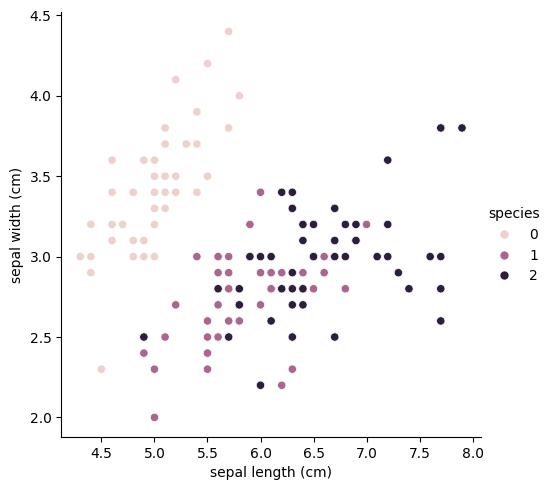

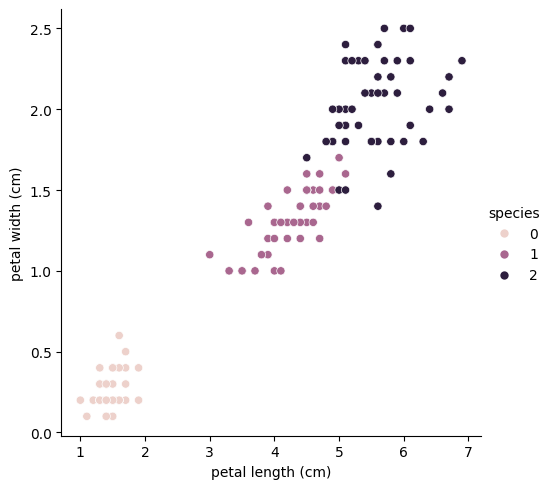

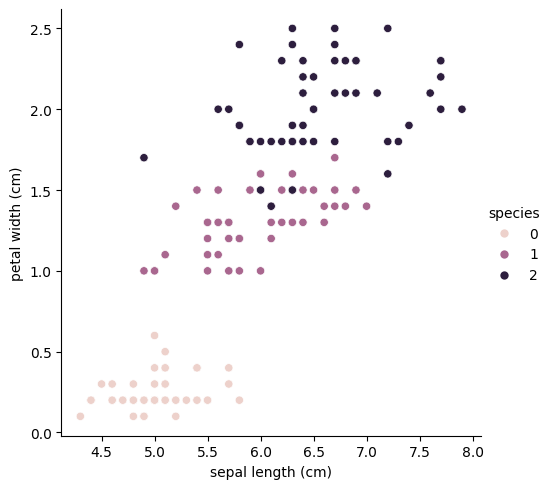

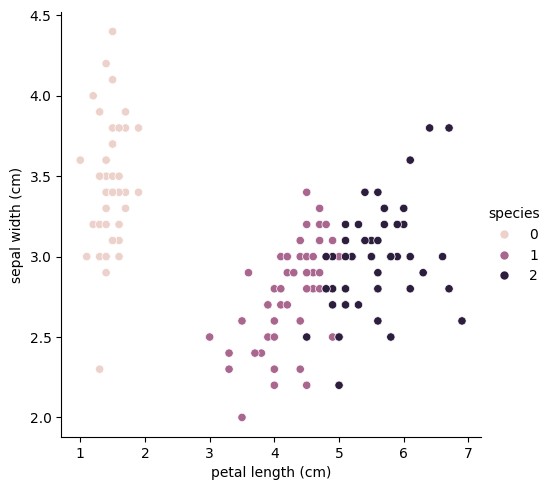

In [14]:
import seaborn as sns

iris_df = input_iris_df.copy()
iris_df['species'] = target_iris_df

sns.relplot(data=iris_df, x="sepal length (cm)", y="sepal width (cm)", hue="species")
sns.relplot(data=iris_df, x="petal length (cm)", y="petal width (cm)", hue="species")
sns.relplot(data=iris_df, x="sepal length (cm)", y="petal width (cm)", hue="species")
sns.relplot(data=iris_df, x="petal length (cm)", y="sepal width (cm)", hue="species")

Now onto modelling per se.

Separating between test and train datasets is key in machine learning, since we want our model to generalize well. The train set is fed to the algorithm, the test set is used to assess performance on unseen data. 

If we're going to slightly nitpick, it is even advised to have train vs validation vs test (train = fed to the algorithm, validation = used to assess the correct hyper-parameters for the model, test = used to assess performance). You'd then perform the split below twice. For the sake of this lesson and since we're not going to tinker much around hyper-parameters, however, we'll simply split between test and train. 

In [15]:
from sklearn.model_selection import train_test_split

input_iris_train, input_iris_test, target_iris_train, target_iris_test = \
  train_test_split(input_iris_df, target_iris_df, test_size = 0.5, random_state = 0)

# All shapes should be (number_of_obs, number_of_columns). 
# In the case of a vector (target), the number of columns can be empty

print(input_iris_train.shape)
print(target_iris_train.shape)
print(input_iris_test.shape)
print(target_iris_test.shape)

# All good for a 50/50 split!

input_iris_test

(75, 4)
(75,)
(75, 4)
(75,)


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
114,5.8,2.8,5.1,2.4
62,6.0,2.2,4.0,1.0
33,5.5,4.2,1.4,0.2
107,7.3,2.9,6.3,1.8
7,5.0,3.4,1.5,0.2
...,...,...,...,...
111,6.4,2.7,5.3,1.9
95,5.7,3.0,4.2,1.2
20,5.4,3.4,1.7,0.2
15,5.7,4.4,1.5,0.4


### Fitting and evaluating a model with scikit-learn

Among the many models available in scikit-learn, we're going to choose a random forest, which is a collection of small decision trees. You can read more about it if that sounds interesting to you!

In [16]:
from sklearn.ensemble import RandomForestClassifier

classifier = RandomForestClassifier().fit(input_iris_train, target_iris_train)

# dir(classifier)

In [17]:
print(f"Our classifier's mean accuracy on the train set is {classifier.score(input_iris_train, target_iris_train)*100}%")
print(f"Our classifier's mean accuracy on the test set is {classifier.score(input_iris_test, target_iris_test)*100}%")

Our classifier's mean accuracy on the train set is 100.0%
Our classifier's mean accuracy on the test set is 93.33333333333333%


Contrary to our regular econometrics, we don't look so much at the contribution of each factor, but rather about how many data points our model correctly characterizes, and how many it misses. Machine learning practitioners hence often look at three metrics:

- Accuracy is the share of observations that are correctly classified as belonging to class A among all the observations that the model classified as A. When it is low, the model is not discriminative enough.
- Recall is the share of observations that are correctly classified as belonging to class A among all the observations that belong to class A. When it is low, the model is not sensitive enough.
- The f1-score is the harmonic mean between precision and recall. It is often used as the metric that summarises model quality. 

We only have time to scratch the surface here, but do feel free to look up these concepts to gain a deeper understanding of them: they are very meaningful to choose the right model for your problem. Also do look up how machine learning practitioners evaluate regression models. 

In [18]:
from sklearn.metrics import precision_score, recall_score, f1_score

# We use the .predict method to apply the model to our test data
input_iris_pred_test = classifier.predict(input_iris_test)

# We compute metrics to assess our model's efficiency.

test_precision = precision_score(input_iris_pred_test, target_iris_test, average = 'weighted')
test_recall = recall_score(input_iris_pred_test, target_iris_test, average = 'weighted')
test_f1 = f1_score(input_iris_pred_test, target_iris_test, average = 'weighted')

print(f"On the test set, our classifier's precision is {round(test_precision, 3)}. Its recall is {round(test_recall, 3)}. The f1, which is the harmonic mean between precision and recall, is {round(test_f1, 3)}")

On the test set, our classifier's precision is 0.939. Its recall is 0.933. The f1, which is the harmonic mean between precision and recall, is 0.934


### What if I still want to understand what goes on inside my model?

In the introduction of this section, we opposed econometrics, that tried to understand relationships between variables, and machine learning, that merely attempted to predict things. This is of course a reductive way to look at things. Machine learning often has the (not so usurped) reputation of being really black box, and not allowing users to understand how prediction truly happens, but this can sometimes lead to disastrous results and should be avoided. Endogeneity does not cease being an issue the second you leave your econometrics class! 

There are a couple of Python library that allow you to lift the cover of the black box, often based on game theory concepts : eli5, LIME or shap. (Again, this is fascinating theory that we have absolutely no time to get into, but if this stimulates your curiosity, you should check out Shapley values, for instance!).

Here is an example with shap:

In [19]:
import shap

pred = classifier.predict_proba(input_iris_test)

explainer = shap.TreeExplainer(classifier)
explanation = explainer(input_iris_test)

shap_values = explanation.values

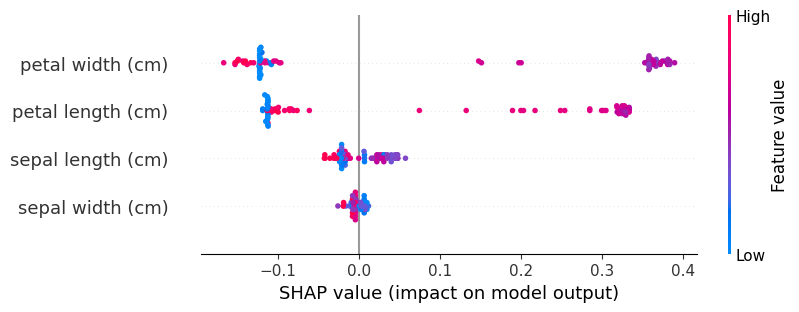

In [20]:
shap.plots.beeswarm(explanation[:, :, 1])  